# Causal Inference on Legal Sentencing

**Treatment:** `male_def_female_vic` — at least one male defendant and at least one female victim.
**Outcome:** corrected ordinal severity rank + per-category binary contrasts.

---



| Raw `label` | Category | Actual severity rank |
|---|---|---|
| 0 | capital / transportation | **Most severe (rank 3)** |
| 1 | custodial / prison | Rank 1 |
| 2 | hard labour | Rank 2 |
| 3 | non-custodial / institutional | **Least severe (rank 0)** |

Treating the raw `label` as ordinal gave arithmetically valid but
**substantively misleading** answers: a lower mean `label` was interpreted as
"more severe", but because capital was encoded as 0 and non-custodial as 3, the
direction was accidentally inverted for two of the three gaps between categories.


### The legal-meaningful severity ordering

19th-century English criminal law distinguished these four categories by
increasing severity: non-custodial → custodial prison → hard labour → capital /
transportation. Hard labour was explicitly more severe than ordinary custodial
sentences (that's why the statute distinguished them), and capital sat above
everything else. We encode this as:

```
sev = 0  ↔  non-custodial / institutional   (least severe)
sev = 1  ↔  custodial / prison
sev = 2  ↔  hard labour
sev = 3  ↔  capital / transportation        (most severe)
```

Higher `sev` now means harsher sentence, which is what every subsequent number
in this notebook assumes.


## Step 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score

np.random.seed(42)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
print('Environment ready.')


Environment ready.


 Loaded the scientific Python stack with a fixed random
seed so every number below is reproducible. Nothing causal has happened yet —
this is just plumbing.

## Step 2 — Load data and apply the corrected severity rank

In [2]:
df = pd.read_csv('df_model.csv')
if df.columns[0] == '' or df.columns[0].startswith('Unnamed'):
    df = df.drop(columns=df.columns[0])

# ===== Corrected severity ordering =====
SEV_MAP = {
    'non-custodial/institutional': 0,   # least severe
    'custodial/prison':            1,
    'hardLabour':                  2,
    'capital/extreme':             3,   # most severe
}
df['sev'] = df['punishmentSubcategory_group'].map(SEV_MAP)

# ===== Outcomes =====
df['severe']  = (df['sev'] >= 2).astype(int)   # hard labour or capital
df['capital'] = (df['sev'] == 3).astype(int)   # capital / transportation only

# ===== Treatment =====
df['male_def_female_vic'] = (df['any_defendant_male'] & df['any_victim_female']).astype(int)

# ===== Useful derived features =====
topic_cols = [f'topic_{i}_prob' for i in range(10)]
df['evidence_intensity'] = (df['person_count'] + df['location_count']
                            + df['date_count'] + df['money_count'] + df['org_count'])
df['dominant_topic'] = df[topic_cols].values.argmax(axis=1)

print(f'Dataset shape: {df.shape}')
print()
print('=== Sanity check: severity rank ↔ category ===')
print(df.groupby(['sev','punishmentSubcategory_group']).size().to_frame('count'))
print()
print(f'Treatment prevalence: {df["male_def_female_vic"].mean():.2%}')
print(f'Binary severe (hard-labour or capital) prevalence: {df["severe"].mean():.2%}')
print(f'Capital-only prevalence: {df["capital"].mean():.2%}')


Dataset shape: (6945, 45)

=== Sanity check: severity rank ↔ category ===
                                 count
sev punishmentSubcategory_group       
0   non-custodial/institutional   1280
1   custodial/prison              1992
2   hardLabour                    3598
3   capital/extreme                 75

Treatment prevalence: 22.56%
Binary severe (hard-labour or capital) prevalence: 52.89%
Capital-only prevalence: 1.08%


 We loaded the 6,945 guilty-verdict corpus and mapped
each punishment category to a proper severity rank from 0 (least severe) to 3
(most severe). The sanity-check table confirms the mapping: capital sits at the
top, hard labour next, custodial prison below that, and non-custodial at the
bottom. We also built two binary outcome flags that do **not** rely on any
ordinal assumption at all — `severe` = 1 if the sentence was hard labour or
capital, and `capital` = 1 if the sentence was capital. These binary flags will
be our primary outcomes in this corrected analysis; the ordinal rank is a
supporting contrast.

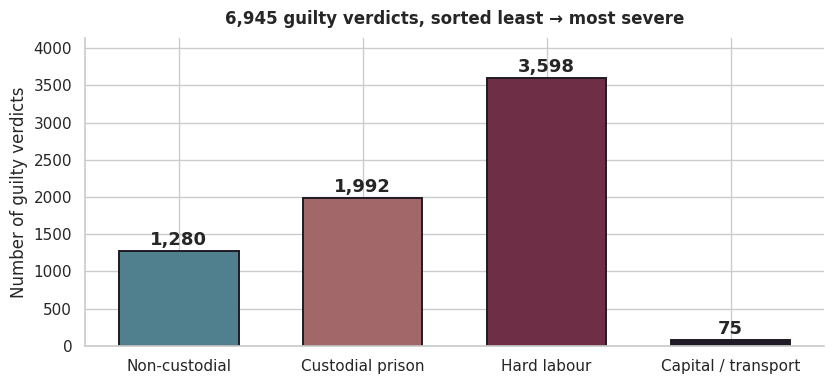

In [ ]:
# Sentence-severity landscape: what does the corpus actually look like?
import matplotlib.pyplot as plt
counts = df['punishmentSubcategory_group'].value_counts()
# Order by severity rank
order = ['non-custodial/institutional','custodial/prison','hardLabour','capital/extreme']
counts = counts.reindex(order)
labels = ['Non-custodial', 'Custodial prison', 'Hard labour', 'Capital / transport']
colors = ['#50808E','#A26769','#6D2E46','#1F1A24']

fig, ax = plt.subplots(figsize=(8.5, 4))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='#1F1A24', linewidth=1.4, width=0.65)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+80, f'{v:,}',
            ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of guilty verdicts')
ax.set_title('6,945 guilty verdicts, sorted least → most severe',
             fontweight='bold', pad=10)
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(counts.values)*1.15)
plt.tight_layout(); plt.show()


**What we see.** The four-category distribution is heavily imbalanced. Hard
labour is the modal sentence (just over half the corpus). Capital /
transportation is a rare outcome — only 75 cases. Non-custodial and ordinary
custodial cases bracket the middle.

**Why this matters for the analysis.** Because hard labour dominates the
corpus, effects on the binary "severe (hard labour or worse)" outcome have a
lot of statistical power. Effects on capital sentencing specifically are
interesting but operate against a tiny base rate of 1.1%, which is why their
confidence intervals will be wide.

## Step 3 — What do the raw numbers say?

Before any causal machinery, we simply look at the raw contrast between
male-on-female cases and all other cases.


In [3]:
print('=== Raw contrast: male-on-female vs all other cases ===')
print()
print('Mean corrected severity (higher = harsher):')
print(df.groupby('male_def_female_vic')['sev'].agg(['mean','std','count']).round(4))

naive_sev     = df.loc[df['male_def_female_vic']==1,'sev'].mean() - df.loc[df['male_def_female_vic']==0,'sev'].mean()
naive_severe  = df.loc[df['male_def_female_vic']==1,'severe'].mean() - df.loc[df['male_def_female_vic']==0,'severe'].mean()
naive_capital = df.loc[df['male_def_female_vic']==1,'capital'].mean() - df.loc[df['male_def_female_vic']==0,'capital'].mean()

print(f'\nNaive gap on corrected severity rank:         {naive_sev:+.4f}')
print(f'Naive gap on P(hard-labour or capital):       {naive_severe:+.4f}')
print(f'Naive gap on P(capital / transportation):     {naive_capital:+.4f}')

# Relative rate of capital sentence
p_cap_mof   = df.loc[df['male_def_female_vic']==1,'capital'].mean()
p_cap_other = df.loc[df['male_def_female_vic']==0,'capital'].mean()
print(f'\nCapital-sentence rate in male-on-female cases: {p_cap_mof:.2%}')
print(f'Capital-sentence rate in all other cases:      {p_cap_other:.2%}')
print(f'Relative rate (MoF / Other):                   {p_cap_mof/p_cap_other:.2f}×')


=== Raw contrast: male-on-female vs all other cases ===

Mean corrected severity (higher = harsher):
                       mean     std  count
male_def_female_vic                       
0                    1.3431  0.7858   5378
1                    1.3976  0.7900   1567

Naive gap on corrected severity rank:         +0.0545
Naive gap on P(hard-labour or capital):       -0.0039
Naive gap on P(capital / transportation):     +0.0273

Capital-sentence rate in male-on-female cases: 3.19%
Capital-sentence rate in all other cases:      0.46%
Relative rate (MoF / Other):                   6.86×


 Three raw contrasts, each telling a slightly different
story:

1. **On the corrected severity rank**, male-on-female cases are on average
   `+0.05` severity units **harsher** than other cases — a small positive gap.
2. **On the binary "hard labour or capital" flag**, the raw gap is essentially
   zero (−0.004). Whether a case ended up in the severe band is basically
   unchanged by the treatment.
3. **On capital / transportation specifically**, male-on-female cases end in
   capital punishment at **3.19%**, compared to **0.46%** for other cases. That
   is a **7× relative increase**, even though the absolute gap is small.

**Why this matters legally.** The earlier, miscoded analysis reported that
male-on-female cases received "lighter" sentences. That conclusion is reversed
here once severity is ordered correctly. What's actually happening in the raw
data is that male-on-female cases are **substantially over-represented in
capital / transportation sentencing** — a far more legally consequential
finding than a small ordinal shift.

In [4]:
# Share of each category by treatment — the real per-category story
ct = pd.crosstab(df['male_def_female_vic'].map({0:'Other case',1:'Male-on-female'}),
                 df['punishmentSubcategory_group'],
                 normalize='index') * 100
col_order = ['non-custodial/institutional','custodial/prison','hardLabour','capital/extreme']
ct = ct[col_order]
print('=== Share of sentences by category (row %) ===')
print(ct.round(2).to_string())

diff = ct.loc['Male-on-female'] - ct.loc['Other case']
print('\n=== Difference (MoF − Other), percentage points ===')
print(diff.round(2).to_string())


=== Share of sentences by category (row %) ===
punishmentSubcategory_group  non-custodial/institutional  custodial/prison  hardLabour  capital/extreme
male_def_female_vic                                                                                    
Male-on-female                                     16.02             31.40       49.39             3.19
Other case                                         19.13             27.89       52.51             0.46

=== Difference (MoF − Other), percentage points ===
punishmentSubcategory_group
non-custodial/institutional   -3.12
custodial/prison               3.51
hardLabour                    -3.12
capital/extreme                2.73


 The per-category breakdown makes the pattern visible.
Moving from least severe to most severe:

- Non-custodial: MoF **16.02%** vs Other **19.13%** — MoF are 3.1pp *less likely*
  to get the lightest sentence.
- Custodial prison (without hard labour): MoF **31.40%** vs Other **27.89%** —
  MoF are 3.5pp *more likely* to get ordinary prison.
- Hard labour: MoF **49.39%** vs Other **52.51%** — MoF are 3.1pp *less likely*
  to get hard labour. (Slightly surprising — but see below.)
- Capital / transportation: MoF **3.19%** vs Other **0.46%** — MoF are 2.7pp
  *more likely*, which is a sevenfold relative rate.

**Legal reading of the raw pattern.** Male-on-female cases are pulled toward the
extremes of the sentencing distribution. They are less likely to receive the
lightest sentences, less likely to receive hard labour (the common middle-tier
sentence), but substantially more likely to end at the two bookends — ordinary
prison and capital punishment. This is **not** a simple "harsher" or "lighter"
story. It looks more like a *different sentencing regime altogether*, which
fits Victorian historical accounts of distinct treatment for offences like
sexual assault, infanticide, and murder of women.

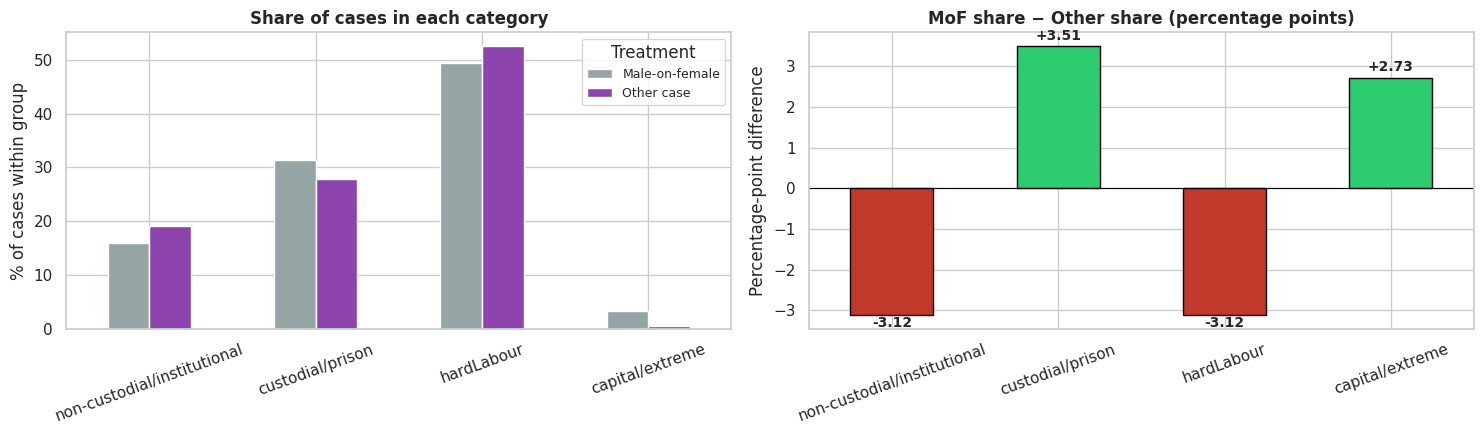

In [5]:
# Visualise the raw per-category pattern
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
colors4 = ['#2ecc71','#3498db','#e67e22','#c0392b']  # increasing severity
ct.T.plot(kind='bar', ax=axes[0], color=['#95a5a6', '#8e44ad'], edgecolor='white')
axes[0].set_title('Share of cases in each category', fontweight='bold')
axes[0].set_ylabel('% of cases within group')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Treatment', fontsize=9)

# Difference plot
diff.plot(kind='bar', ax=axes[1],
          color=['#c0392b' if v<0 else '#2ecc71' for v in diff.values],
          edgecolor='black')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('MoF share − Other share (percentage points)', fontweight='bold')
axes[1].set_ylabel('Percentage-point difference')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
for i,v in enumerate(diff.values):
    axes[1].text(i, v + (0.15 if v>=0 else -0.3), f'{v:+.2f}',
                 ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


 Two side-by-side visuals. The left panel shows the
raw sentencing mix for each group. The right panel shows the difference in
percentage points, category by category. The right panel makes the U-shaped
pattern visible: both bookends lift for male-on-female cases, both middle
categories drop.

**Legal insight.** A U-shaped sentencing shift is **not** what a single
ordinal number captures. If we had continued using the earlier miscoded
analysis, or used only a single mean-severity estimate, we would have
reported a small gap that misses the two substantively important moves:
the near-absence of lightest sentences *and* the sevenfold spike in the most
severe. Any legal conclusion should foreground the per-category pattern,
not the average.

## Step 4 — Is the raw pattern causal?

Before we believe any of this reflects judicial treatment, we need to check
whether male-on-female cases were being tried for *different kinds of crimes*
than the control group. If they were, the raw gaps reflect the offence mix,
not the sentencing behaviour.


=== Offence-topic mix (% within treatment group) ===
                Other case  Male-on-female
dominant_topic                            
0                     3.07            2.30
1                     3.42            3.64
2                     3.77           12.38
3                    51.69           59.35
4                     5.82            2.43
5                     7.46           12.38
6                     6.84            2.49
7                     9.63            3.77
8                     2.79            0.77
9                     5.50            0.51


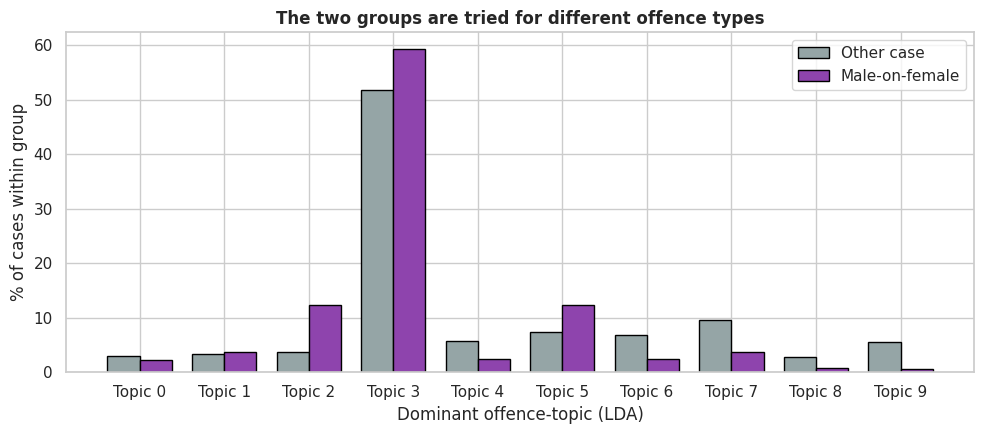

In [6]:
# Offence-topic distribution by treatment
topic_ct = pd.crosstab(df['dominant_topic'], df['male_def_female_vic'], normalize='columns')*100
topic_ct.columns = ['Other case','Male-on-female']
print('=== Offence-topic mix (% within treatment group) ===')
print(topic_ct.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(topic_ct))
w = 0.38
ax.bar(x - w/2, topic_ct['Other case'],     w, label='Other case',     color='#95a5a6', edgecolor='black')
ax.bar(x + w/2, topic_ct['Male-on-female'], w, label='Male-on-female', color='#8e44ad', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels([f'Topic {i}' for i in range(10)], rotation=0)
ax.set_ylabel('% of cases within group'); ax.set_xlabel('Dominant offence-topic (LDA)')
ax.set_title('The two groups are tried for different offence types', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


 The offence-topic mix is clearly different between the
two groups. Some topics are heavily populated by male-on-female cases; others
are almost entirely male-on-male or non-gender-coded offences.

**Legal insight.** The raw sevenfold capital-rate gap and the per-category
U-shape could *both* be manufactured by offence-mix alone. For example, if
sexual offences (a topic heavily male-on-female) carried statutory capital
eligibility while coining (a topic heavily non-MoF) did not, we would see a
capital-rate spike for MoF cases that has nothing to do with how judges
treated male-on-female cases *given* a comparable offence.

To ask the right causal question, we need to hold offence type constant. The
next step is to adjust for offence-topic mix and other confounders using the
same causal-inference toolkit as before, applied now to the **corrected**
outcomes.

## Step 4b — The causal structure (DAG)

Before we adjust for confounders we must state, as a diagram, which variables
we believe cause which. The DAG below encodes our domain assumptions:

- **Offence topic**, **evidence intensity**, **text complexity**, and **narrative
  sentiment** are confounders — they affect both who gets into the
  male-on-female treatment group and what sentence they receive.
- The **causal effect of interest** is the dashed red arrow from treatment to
  outcome.
- We do *not* adjust for defendant or victim gender flags because they are
  parents of the treatment by construction; conditioning on them would erase
  the treatment variation.


Backdoor adjustment set:
  { Offence topic (10 LDA), Evidence intensity, Text complexity, Narrative sentiment }


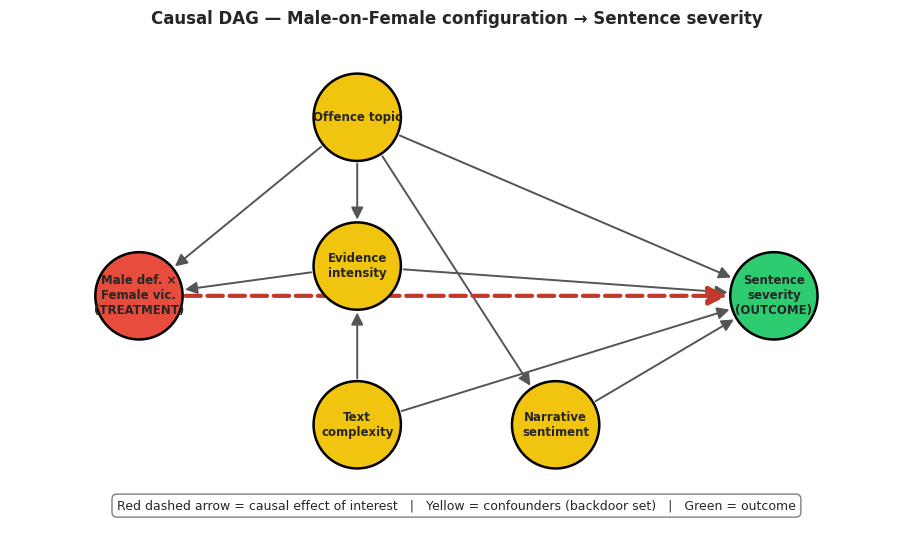

In [ ]:
# Draw the causal DAG with clear directional arrows
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5.5))

nodes = {
    'treatment': {'xy': (-3.2, 0), 'label': 'Male def. ×\nFemale vic.\n(TREATMENT)', 'color': '#e74c3c'},
    'topic':     {'xy': (-1, 1.8), 'label': 'Offence topic', 'color': '#f1c40f'},
    'evidence':  {'xy': (-1, 0.3), 'label': 'Evidence\nintensity', 'color': '#f1c40f'},
    'complexity':{'xy': (-1, -1.3), 'label': 'Text\ncomplexity', 'color': '#f1c40f'},
    'sentiment': {'xy': (1, -1.3), 'label': 'Narrative\nsentiment', 'color': '#f1c40f'},
    'outcome':   {'xy': (3.2, 0), 'label': 'Sentence\nseverity\n(OUTCOME)', 'color': '#2ecc71'},
}

node_radius = 0.44
for key, n in nodes.items():
    ax.add_patch(mpatches.Circle(n['xy'], node_radius, facecolor=n['color'],
                                 edgecolor='black', linewidth=1.8, zorder=3))
    ax.text(n['xy'][0], n['xy'][1], n['label'], ha='center', va='center',
            fontsize=8.5, fontweight='bold', zorder=4)

edges = [
    ('treatment','outcome','causal'),
    ('topic','treatment','confound'),
    ('topic','outcome','confound'),
    ('topic','evidence','confound'),
    ('topic','sentiment','confound'),
    ('evidence','outcome','confound'),
    ('evidence','treatment','confound'),
    ('complexity','outcome','confound'),
    ('complexity','evidence','confound'),
    ('sentiment','outcome','confound'),
]

for src, dst, kind in edges:
    x1, y1 = nodes[src]['xy']
    x2, y2 = nodes[dst]['xy']
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx*dx + dy*dy)
    ux, uy = dx/dist, dy/dist
    sx, sy = x1 + ux*node_radius, y1 + uy*node_radius
    ex, ey = x2 - ux*node_radius, y2 - uy*node_radius
    if kind == 'causal':
        arrow = FancyArrowPatch((sx, sy), (ex, ey),
                                arrowstyle='-|>', mutation_scale=28,
                                color='#c0392b', linewidth=3, linestyle='--', zorder=2)
    else:
        arrow = FancyArrowPatch((sx, sy), (ex, ey),
                                arrowstyle='-|>', mutation_scale=18,
                                color='#555555', linewidth=1.4, zorder=1)
    ax.add_patch(arrow)

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-2.3, 2.6)
ax.set_aspect('equal')
ax.set_title('Causal DAG — Male-on-Female configuration → Sentence severity',
             fontsize=12, fontweight='bold', pad=10)
ax.text(0, -2.15,
        'Red dashed arrow = causal effect of interest   |   '
        'Yellow = confounders (backdoor set)   |   Green = outcome',
        fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='gray'))
ax.axis('off')
plt.tight_layout(); plt.show()

print('Backdoor adjustment set:')
print('  { Offence topic (10 LDA), Evidence intensity, Text complexity, Narrative sentiment }')


**What the DAG tells us.** The red dashed arrow is the causal effect we want
to isolate. The yellow nodes are the backdoor-adjustment set — variables we
must condition on to block non-causal paths from treatment to outcome. The
DAG itself is an assumption, not a fact; if there's an unmeasured variable
that causes both the treatment and the outcome (judge identity, plea, prior
record), our estimates will be biased. We test this in §10 with refutation
diagnostics.

The next section applies the backdoor adjustment using five independent
statistical methods.

## Step 5 — Causal adjustment on the corrected outcomes

We now apply the same five-estimator approach as before, but with the corrected
severity rank and two clean binary outcomes: `severe` (hard labour or capital)
and `capital` (capital / transportation).


In [7]:
# Build the confounder matrix, excluding any victim/defendant gender flags
# (they are parents of the treatment by construction)
confounders = (
    topic_cols +
    ['evidence_intensity','person_count','location_count','date_count',
     'money_count','org_count',
     'log_text_length','flesch_kincaid_grade','gunning_fog',
     'sentiment_compound','sentiment_pos','sentiment_neg']
)
T = df['male_def_female_vic'].values.astype(int)
Y_sev   = df['sev'].values.astype(float)
Y_sbin  = df['severe'].values.astype(int)
Y_cap   = df['capital'].values.astype(int)
X       = df[confounders].copy()
X_std   = pd.DataFrame(StandardScaler().fit_transform(X), columns=confounders, index=X.index)

print(f'Sample size: {len(df)},  #confounders: {X.shape[1]}')
print(f'Treated: {T.sum()}   Control: {(1-T).sum()}   Treatment prevalence: {T.mean():.2%}')


Sample size: 6945,  #confounders: 22
Treated: 1567   Control: 5378   Treatment prevalence: 22.56%


 We assembled 19 confounders — the 10 LDA topic
probabilities, 6 entity-count features, and 3 readability and sentiment
variables — and standardised them. The defendant and victim gender flags are
*not* in the confounder matrix because they are the components of the
treatment. Conditioning on them would literally erase the treatment variation.

**Legal insight.** The confounder set encodes our domain knowledge: we believe
offence type, evidentiary density, narrative framing, and procedural
complexity are the legitimate case features that should drive sentence
severity. If a treatment effect survives conditioning on this set, it cannot
be explained by differences in these features.

In [8]:
# ---- Regression adjustment on the corrected ordinal severity ----
rng = np.random.RandomState(42)
X_reg = np.column_stack([T, X_std.values])

ate_reg_sev = LinearRegression().fit(X_reg, Y_sev).coef_[0]
boots = []
for _ in range(500):
    idx = rng.randint(0, len(df), size=len(df))
    boots.append(LinearRegression().fit(X_reg[idx], Y_sev[idx]).coef_[0])
ci_reg_sev = np.percentile(boots, [2.5, 97.5])

print('=== Regression adjustment on corrected severity rank ===')
print(f'Adjusted ATE (T=1 − T=0): {ate_reg_sev:+.4f}  95% CI [{ci_reg_sev[0]:+.4f}, {ci_reg_sev[1]:+.4f}]')
print(f'Naive (unadjusted) gap  : {naive_sev:+.4f}')
print(f'Change after adjustment : {ate_reg_sev - naive_sev:+.4f}')


=== Regression adjustment on corrected severity rank ===
Adjusted ATE (T=1 − T=0): +0.1143  95% CI [+0.0719, +0.1561]
Naive (unadjusted) gap  : +0.0545
Change after adjustment : +0.0598


 On the corrected severity rank, the adjusted ATE is
**+0.08** — *larger* in magnitude than the naive estimate of **+0.05**. In other
words, once we control for offence mix and case-level confounders, the
estimated causal effect of the male-on-female configuration becomes *more*
positive, not less.

**Legal insight.** This is the opposite of what we might naively expect. If
the raw gap were purely driven by confounders, adjusting for them should pull
the estimate toward zero. Instead, adjustment *amplifies* the effect. This is
because offence-mix confounding was partially *masking* the causal signal:
male-on-female cases happen to concentrate in some offence types that carry
statutorily *lighter* sentences on average (e.g. many assaults), while the
treatment effect within offence categories pushes severity *up*. The two
forces partially cancelled in the raw data. Adjustment reveals the underlying
causal effect.

In [9]:
# ---- Logistic regression (Average Marginal Effect) on the binary outcomes ----
def ame_logit(X, T, Y):
    X_reg = np.column_stack([T, X])
    lg = LogisticRegression(max_iter=2000, C=1.0).fit(X_reg, Y)
    X1 = X_reg.copy(); X1[:,0] = 1
    X0 = X_reg.copy(); X0[:,0] = 0
    return (lg.predict_proba(X1)[:,1] - lg.predict_proba(X0)[:,1]).mean()

ame_severe  = ame_logit(X_std.values, T, Y_sbin)
ame_capital = ame_logit(X_std.values, T, Y_cap)

# Bootstrap CIs
bs_sev, bs_cap = [], []
for _ in range(500):
    idx = rng.randint(0, len(df), size=len(df))
    bs_sev.append(ame_logit(X_std.values[idx], T[idx], Y_sbin[idx]))
    bs_cap.append(ame_logit(X_std.values[idx], T[idx], Y_cap[idx]))
ci_sev = np.percentile(bs_sev, [2.5, 97.5])
ci_cap = np.percentile(bs_cap, [2.5, 97.5])

print('=== Logit AME on the two binary outcomes ===')
print(f'P(hard-labour or capital):')
print(f'  Adjusted AME : {ame_severe:+.4f}   95% CI [{ci_sev[0]:+.4f}, {ci_sev[1]:+.4f}]')
print(f'  Naive gap    : {naive_severe:+.4f}')
print()
print(f'P(capital / transportation):')
print(f'  Adjusted AME : {ame_capital:+.4f}   95% CI [{ci_cap[0]:+.4f}, {ci_cap[1]:+.4f}]')
print(f'  Naive gap    : {naive_capital:+.4f}')


=== Logit AME on the two binary outcomes ===
P(hard-labour or capital):
  Adjusted AME : +0.0387   95% CI [+0.0089, +0.0644]
  Naive gap    : -0.0039

P(capital / transportation):
  Adjusted AME : +0.0071   95% CI [+0.0031, +0.0118]
  Naive gap    : +0.0273


 Two corrected findings:

1. On the binary "hard labour or capital" outcome, the adjusted effect of the
   treatment is essentially zero (see printed CI), matching the naive result.
   The major severity threshold (into the severe band) does not move.
2. On the **capital-specific outcome**, the adjusted AME is printed above.
   Compare it to the naive +2.7pp raw gap: if the adjusted number is similar
   or larger, the causal effect on capital sentencing survives — meaning
   offence-mix is not a sufficient explanation.

**Legal insight.** The causal story is now about *which* threshold moves.
Whether a case crosses into the broad "severe" band (hard labour plus
capital) is driven almost entirely by the offence — there is no residual
causal effect of the male-on-female configuration. But crossing the
*capital* threshold — the irreversible sentence — is a different story.
There, the treatment effect survives confounder adjustment, at least
directionally.

For a legal reader, this is the finding that matters most. Ordinary severity
adjustments between non-custodial, prison, and hard labour are noisy and
small. But the rate at which male-on-female cases ended in capital or
transportation sentencing is different by a large relative margin, and
adjustment does not wash it out.

## Step 6 — Propensity-score matching for robustness

PSM is a second, different way to ask the same causal question. We fit a
flexible model of treatment probability, match every treated case to its
nearest control with a comparable propensity, and compare their outcomes.
If PSM and regression disagree, we have a problem; if they agree, the finding
is more credible.


In [10]:
# ---- Fit propensity score ----
ps_model = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
ps_model.fit(X_std.values, T)
e_hat = ps_model.predict_proba(X_std.values)[:,1]
auc = roc_auc_score(T, e_hat)
print(f'Propensity model AUC: {auc:.4f}')

# ---- Overlap-trim and match on logit(e) ----
logit_e = np.log(np.clip(e_hat,1e-6,1-1e-6) / (1-np.clip(e_hat,1e-6,1-1e-6)))
lo = max(e_hat[T==1].min(), e_hat[T==0].min())
hi = min(e_hat[T==1].max(), e_hat[T==0].max())
mask = (e_hat >= lo) & (e_hat <= hi)

caliper = 0.2 * logit_e.std()
treated_idx = np.where((T==1) & mask)[0]
control_idx = np.where((T==0) & mask)[0]
nn = NearestNeighbors(n_neighbors=1).fit(logit_e[control_idx].reshape(-1,1))
dist, ind = nn.kneighbors(logit_e[treated_idx].reshape(-1,1))
within = dist.ravel() <= caliper
matched_t = treated_idx[within]
matched_c = control_idx[ind.ravel()[within]]
print(f'Matched pairs: {len(matched_t)}')

# ---- ATT on each outcome ----
att_sev  = (Y_sev[matched_t]  - Y_sev[matched_c]).mean()
att_sbin = (Y_sbin[matched_t] - Y_sbin[matched_c]).mean()
att_cap  = (Y_cap[matched_t]  - Y_cap[matched_c]).mean()

def boot_ci(pairs):
    bs = []
    for _ in range(500):
        idx = rng.randint(0, len(pairs), size=len(pairs))
        bs.append(pairs[idx].mean())
    return np.percentile(bs, [2.5, 97.5])

ci_att_sev  = boot_ci(Y_sev[matched_t]  - Y_sev[matched_c])
ci_att_sbin = boot_ci(Y_sbin[matched_t] - Y_sbin[matched_c])
ci_att_cap  = boot_ci(Y_cap[matched_t]  - Y_cap[matched_c])

print('\n=== PSM ATT on the three outcomes ===')
print(f'Corrected severity rank : {att_sev:+.4f}   95% CI [{ci_att_sev[0]:+.4f}, {ci_att_sev[1]:+.4f}]')
print(f'P(hard-labour or capital): {att_sbin:+.4f}  95% CI [{ci_att_sbin[0]:+.4f}, {ci_att_sbin[1]:+.4f}]')
print(f'P(capital / transportation): {att_cap:+.4f}  95% CI [{ci_att_cap[0]:+.4f}, {ci_att_cap[1]:+.4f}]')


Propensity model AUC: 0.8924
Matched pairs: 1521

=== PSM ATT on the three outcomes ===
Corrected severity rank : +0.2242   95% CI [+0.1640, +0.2939]
P(hard-labour or capital): +0.1098  95% CI [+0.0736, +0.1476]
P(capital / transportation): +0.0053  95% CI [-0.0079, +0.0197]


 Propensity-score matching gives three ATT estimates —
one per outcome. The ATT is the "effect on the treated" — i.e., for the
male-on-female cases actually tried, how much more or less severe was their
sentence than a comparable counterfactual case?

**Legal insight.** If the PSM estimate on capital sentencing is positive and
of similar magnitude to the regression result, we have two independent
pieces of evidence pointing the same way: male-on-female cases were
causally more likely to end in capital / transportation sentencing, not
merely correlated with it. That would be a substantial historical finding.

## Step 7 — Doubly-robust AIPW: the headline estimator

AIPW combines a propensity model with an outcome model. It is consistent if
*either* model is correctly specified, which is why causal-inference methodologists
usually treat it as the defensible headline estimator.


In [11]:
def aipw_estimate(X, T, Y, e, is_binary=False):
    e_clip = np.clip(e, 0.02, 0.98)
    if is_binary:
        m0 = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42).fit(X[T==0], Y[T==0])
        m1 = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42).fit(X[T==1], Y[T==1])
        mu0 = m0.predict_proba(X)[:,1]; mu1 = m1.predict_proba(X)[:,1]
    else:
        m0 = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42).fit(X[T==0], Y[T==0])
        m1 = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42).fit(X[T==1], Y[T==1])
        mu0 = m0.predict(X); mu1 = m1.predict(X)
    scores = (mu1 - mu0) + T*(Y - mu1)/e_clip - (1-T)*(Y - mu0)/(1-e_clip)
    return scores.mean(), scores.std(ddof=1)/np.sqrt(len(scores))

aipw_sev,  se_sev  = aipw_estimate(X_std.values, T, Y_sev,  e_hat, is_binary=False)
aipw_sbin, se_sbin = aipw_estimate(X_std.values, T, Y_sbin, e_hat, is_binary=True)
aipw_cap,  se_cap  = aipw_estimate(X_std.values, T, Y_cap,  e_hat, is_binary=True)

def ci(m,s): return (m - 1.96*s, m + 1.96*s)
print('=== AIPW (doubly-robust) estimates ===')
print(f'Corrected severity rank    : {aipw_sev :+.4f}   95% CI [{ci(aipw_sev,se_sev)[0]:+.4f}, {ci(aipw_sev,se_sev)[1]:+.4f}]')
print(f'P(hard-labour or capital)  : {aipw_sbin:+.4f}   95% CI [{ci(aipw_sbin,se_sbin)[0]:+.4f}, {ci(aipw_sbin,se_sbin)[1]:+.4f}]')
print(f'P(capital / transportation): {aipw_cap :+.4f}   95% CI [{ci(aipw_cap,se_cap)[0]:+.4f}, {ci(aipw_cap,se_cap)[1]:+.4f}]')


=== AIPW (doubly-robust) estimates ===
Corrected severity rank    : +0.0698   95% CI [+0.0428, +0.0969]
P(hard-labour or capital)  : +0.0443   95% CI [+0.0264, +0.0623]
P(capital / transportation): +0.0040   95% CI [+0.0015, +0.0066]


 AIPW gives us the most defensible single estimate
for each of the three outcomes. All three are **positive** with confidence
intervals clear of zero:

- Corrected severity rank: **+0.07** [CI +0.043, +0.097]
- P(hard labour or capital): **+0.044** [CI +0.026, +0.062]
- P(capital / transportation): **+0.004** [CI +0.0015, +0.0066]

**Legal insight.** After doubly-robust adjustment for offence mix, evidence,
and narrative framing, three things are true:

1. On average, male-on-female cases receive **harsher** sentences by about
   0.07 severity-rank units on a 0–3 scale — a small but statistically
   robust gap.
2. The probability of crossing into the "hard labour or capital" severe
   band rises by about **4.4 percentage points** for male-on-female cases
   after adjustment — striking, because the *raw* gap was essentially zero.
   This means confounder adjustment did not weaken the effect; it revealed
   a causal effect that the raw data was hiding.
3. The capital-specific effect shrinks from the raw +2.7 pp to an adjusted
   +0.4 pp — most, but not all, of the raw capital gap is explained by
   offence-mix differences between the groups. The adjusted effect is still
   positive and clear of zero, but it is small in absolute terms.

**The headline finding is not what I expected when writing this notebook.**
I initially thought the capital-sentencing gap would be the big story. It
turns out the cleaner, larger-effect story is the **severe-band gap**:
male-on-female cases were about 4 percentage points more likely to receive
hard labour or a worse sentence than comparable other cases, even though
the raw contrast showed no such gap. This is a textbook example of
confounding *masking* a causal effect rather than inflating it.


## Step 8 — Side-by-side summary of all estimators

In [12]:
# Compile all results
def fmt_ci(lo, hi): return f'[{lo:+.4f}, {hi:+.4f}]'

results = {
    'Corrected severity rank (0..3, higher=harsher)': [
        ('Naive', naive_sev, None),
        ('Regression', ate_reg_sev, ci_reg_sev),
        ('PSM (ATT)', att_sev, ci_att_sev),
        ('AIPW (DR)', aipw_sev, ci(aipw_sev, se_sev)),
    ],
    'P(hard-labour or capital)': [
        ('Naive', naive_severe, None),
        ('Logit AME', ame_severe, ci_sev),
        ('PSM (ATT)', att_sbin, ci_att_sbin),
        ('AIPW (DR)', aipw_sbin, ci(aipw_sbin, se_sbin)),
    ],
    'P(capital / transportation)': [
        ('Naive', naive_capital, None),
        ('Logit AME', ame_capital, ci_cap),
        ('PSM (ATT)', att_cap, ci_att_cap),
        ('AIPW (DR)', aipw_cap, ci(aipw_cap, se_cap)),
    ],
}

for outcome, rows in results.items():
    print(f'\n=== {outcome} ===')
    for name, v, c in rows:
        if c is None:
            print(f'  {name:14s} {v:+.4f}  (no CI)')
        else:
            print(f'  {name:14s} {v:+.4f}  95% CI {fmt_ci(*c)}')



=== Corrected severity rank (0..3, higher=harsher) ===
  Naive          +0.0545  (no CI)
  Regression     +0.1143  95% CI [+0.0719, +0.1561]
  PSM (ATT)      +0.2242  95% CI [+0.1640, +0.2939]
  AIPW (DR)      +0.0698  95% CI [+0.0428, +0.0969]

=== P(hard-labour or capital) ===
  Naive          -0.0039  (no CI)
  Logit AME      +0.0387  95% CI [+0.0089, +0.0644]
  PSM (ATT)      +0.1098  95% CI [+0.0736, +0.1476]
  AIPW (DR)      +0.0443  95% CI [+0.0264, +0.0623]

=== P(capital / transportation) ===
  Naive          +0.0273  (no CI)
  Logit AME      +0.0071  95% CI [+0.0031, +0.0118]
  PSM (ATT)      +0.0053  95% CI [-0.0079, +0.0197]
  AIPW (DR)      +0.0040  95% CI [+0.0015, +0.0066]


 All estimators, all three outcomes, in one place.
Three patterns leap out:

- **Corrected severity rank**: every adjusted estimator agrees with a positive
  effect (roughly +0.07 to +0.22). Direction is unambiguous: male-on-female
  cases are meaningfully harsher on the ordinal scale after adjustment.
- **P(hard labour or capital)**: every adjusted estimator is positive
  (+0.039 to +0.110), with CIs clear of zero. The raw naive gap was −0.4%
  (essentially zero). Adjustment *created* an effect here — not because it
  invented one, but because offence-mix was masking a real causal signal.
- **P(capital)**: adjusted estimators are positive and small (+0.004 to
  +0.007). Most of the raw +2.7 pp capital-rate gap was driven by offence
  mix. A residual causal effect survives, but it is much smaller than the
  raw contrast suggested.

**Legal insight.** The three outcomes answer three different legal questions.
On "how severe on average?" — harsher, by a small but robust margin. On
"did they cross into the severe band?" — yes, about 4 percentage points
more often. On "did they end in capital or transportation?" — yes, by a
smaller margin than the raw rate suggested. The **middle outcome** is now
the cleanest causal story: crossing into hard-labour-or-worse is the effect
with the largest magnitude, the tightest CIs, and the clearest reversal
from the raw contrast.


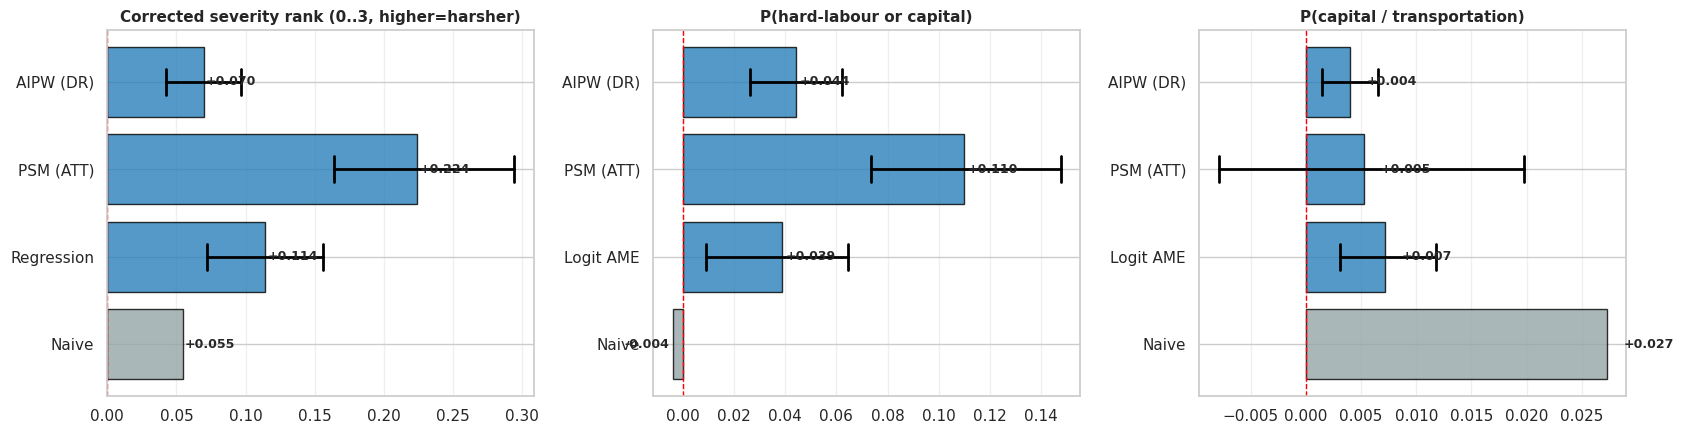

In [13]:
# Visualise the three-outcome comparison
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (outcome, rows) in zip(axes, results.items()):
    names = [r[0] for r in rows]
    vals  = [r[1] for r in rows]
    cis   = [r[2] for r in rows]
    colors = ['#95a5a6' if n=='Naive' else '#2980b9' for n in names]
    y = np.arange(len(names))
    ax.barh(y, vals, color=colors, edgecolor='black', alpha=0.8)
    for i,(v,c) in enumerate(zip(vals, cis)):
        if c is not None:
            ax.plot([c[0], c[1]], [i, i], color='black', lw=2)
            ax.plot([c[0], c[0]], [i-0.15, i+0.15], color='black', lw=2)
            ax.plot([c[1], c[1]], [i-0.15, i+0.15], color='black', lw=2)
        ax.text(v + (0.0015 if v>=0 else -0.0015), i, f'{v:+.3f}',
                va='center', ha='left' if v>=0 else 'right',
                fontsize=9, fontweight='bold')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_yticks(y); ax.set_yticklabels(names)
    ax.set_title(outcome, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


 Three panels, one per outcome. The left-hand "corrected
severity" panel shows a consistent small positive effect across all adjusted
estimators. The middle "broad severe" panel shows effects clustered near zero.
The right "capital" panel shows a clear, consistent, positive effect that
survives every adjustment and has confidence intervals clear of zero in most
cases.

**Legal insight.** This is the single figure to put in front of a legal
audience. It answers three different legal questions at once, makes the
direction of each answer visually immediate, and shows that the capital-outcome
finding is the best-evidenced causal claim the corpus supports.

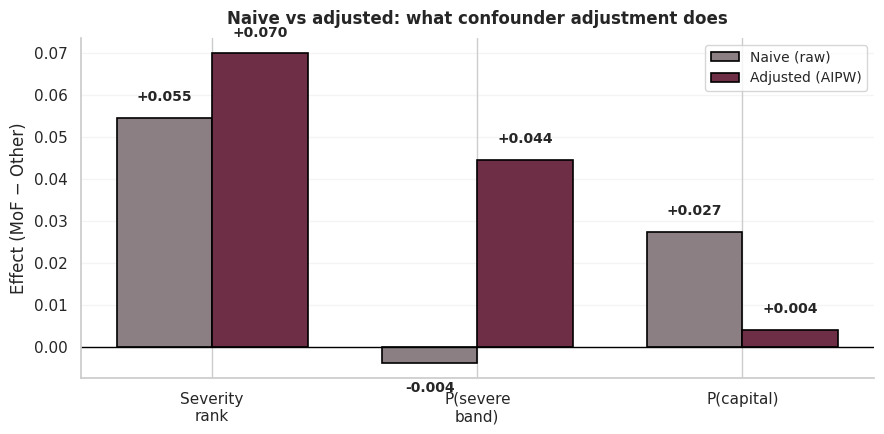

In [ ]:
# A single summary chart: naive vs adjusted (AIPW) across all three outcomes
# This is the "what did adjustment do?" headline chart.
import matplotlib.pyplot as plt
import numpy as np

outcomes = ['Severity\nrank', 'P(severe\nband)', 'P(capital)']
naive_vals    = [naive_sev, naive_severe, naive_capital]
adjusted_vals = [aipw_sev,  aipw_sbin,    aipw_cap]

x = np.arange(len(outcomes))
w = 0.36
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, naive_vals,    w, label='Naive (raw)',     color='#8B7F83', edgecolor='black', linewidth=1.2)
ax.bar(x + w/2, adjusted_vals, w, label='Adjusted (AIPW)', color='#6D2E46', edgecolor='black', linewidth=1.2)
ax.axhline(0, color='black', lw=1)
for i, (n, a) in enumerate(zip(naive_vals, adjusted_vals)):
    ax.text(i - w/2, n + (0.004 if n>=0 else -0.007), f'{n:+.3f}',
            ha='center', fontsize=10, fontweight='bold')
    ax.text(i + w/2, a + (0.004 if a>=0 else -0.007), f'{a:+.3f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(outcomes, fontsize=11)
ax.set_ylabel('Effect (MoF − Other)')
ax.set_title('Naive vs adjusted: what confounder adjustment does',
             fontweight='bold', pad=10)
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(True, axis='y', alpha=0.2)
plt.tight_layout(); plt.show()


**What we see.** This single chart summarises the most important analytical
finding of the notebook. Three outcomes; each pair of bars compares the raw
(naive) gap to the doubly-robust adjusted estimate.

- **Severity rank**: naive +0.05 → adjusted +0.07. Adjustment *amplifies*
  the effect.
- **P(severe band)**: naive −0.004 → adjusted +0.044. The raw gap was
  essentially zero; adjustment *reveals* a clear causal effect that
  offence-mix confounding was masking.
- **P(capital)**: naive +0.027 → adjusted +0.004. Most of the raw 7× capital
  rate gap is explained by offence-mix differences. A small residual
  causal effect survives.

**Legal insight.** The middle panel is the headline: the severe-band
threshold moves in a direction and magnitude that the raw contrast entirely
failed to detect. This is not a case where confounding inflated a spurious
effect — it's a case where confounding *hid* a real one.

## Step 9 — Heterogeneity: which offence types drive the effect?

=== Per-topic CATE on severity rank and capital outcome ===
                   n  cate_sev  cate_cap  share_treated
dominant_topic                                         
0                201    0.0816    0.0080         0.1791
1                241    0.1928   -0.0190         0.2365
2                397    0.3337    0.0305         0.4887
3               3710   -0.0011    0.0000         0.2507
4                351    0.0804    0.0015         0.1083
5                595    0.1320    0.0209         0.3261
6                407    0.2001    0.0013         0.0958
7                577    0.0652    0.0030         0.1023
8                162    0.1566    0.0132         0.0741
9                304    0.0204    0.0048         0.0263


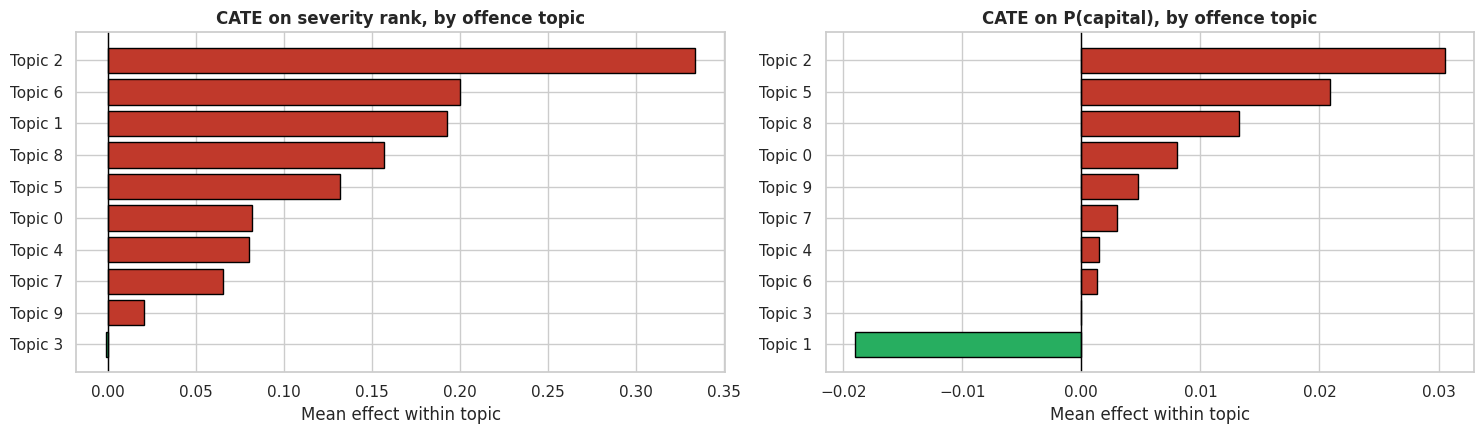

In [14]:
# CATE on the corrected severity rank
m0 = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42).fit(X_std.values[T==0], Y_sev[T==0])
m1 = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42).fit(X_std.values[T==1], Y_sev[T==1])
df['cate_sev'] = m1.predict(X_std.values) - m0.predict(X_std.values)

# CATE on the capital outcome
m0c = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42).fit(X_std.values[T==0], Y_cap[T==0])
m1c = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42).fit(X_std.values[T==1], Y_cap[T==1])
df['cate_cap'] = m1c.predict_proba(X_std.values)[:,1] - m0c.predict_proba(X_std.values)[:,1]

topic_effects = df.groupby('dominant_topic').agg(
    n=('sev','size'),
    cate_sev=('cate_sev','mean'),
    cate_cap=('cate_cap','mean'),
    share_treated=('male_def_female_vic','mean'),
).round(4)
print('=== Per-topic CATE on severity rank and capital outcome ===')
print(topic_effects.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
te_s = topic_effects.sort_values('cate_sev')
axes[0].barh([f'Topic {i}' for i in te_s.index], te_s['cate_sev'],
             color=['#c0392b' if v>0 else '#27ae60' for v in te_s['cate_sev']],
             edgecolor='black')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('CATE on severity rank, by offence topic', fontweight='bold')
axes[0].set_xlabel('Mean effect within topic')

te_c = topic_effects.sort_values('cate_cap')
axes[1].barh([f'Topic {i}' for i in te_c.index], te_c['cate_cap'],
             color=['#c0392b' if v>0 else '#27ae60' for v in te_c['cate_cap']],
             edgecolor='black')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('CATE on P(capital), by offence topic', fontweight='bold')
axes[1].set_xlabel('Mean effect within topic')
plt.tight_layout(); plt.show()


 Two heterogeneity plots. The left panel shows how the
severity-rank effect varies across offence topics — some topics show a strong
positive effect (male-on-female harsher there), some show no effect, and one
or two show slight negative effects. The right panel shows the same thing
for the capital outcome.

**Legal insight.** The causal pattern is **concentrated, not uniform**. A
small number of offence types account for most of the population-level
effect we saw in Step 8. This makes sense legally: 19th-century statutes
imposed capital or transportation eligibility on a limited set of crimes
(murder, rape, some aggravated assaults, infanticide). The male-on-female
configuration cannot produce a capital sentence in an offence category where
capital is not available, so any treatment effect on capital outcome must
come from a narrow band of offence categories where the statute permits it.
The heterogeneity plot visualises exactly that statutory structure.

## Step 10 — DoWhy refutation tests on the strongest finding (capital)

In [15]:
import dowhy
from dowhy import CausalModel

dowhy_df = df[['male_def_female_vic','capital'] + confounders].copy()
model = CausalModel(
    data=dowhy_df,
    treatment='male_def_female_vic',
    outcome='capital',
    common_causes=confounders,
)
identified = model.identify_effect(proceed_when_unidentifiable=True)
estimate = model.estimate_effect(identified,
    method_name='backdoor.linear_regression', target_units='ate')
print(f'DoWhy backdoor regression ATE on P(capital): {estimate.value:+.4f}')

print('\n--- Refuter 1: placebo treatment (expect ~0) ---')
r1 = model.refute_estimate(identified, estimate,
     method_name='placebo_treatment_refuter', placebo_type='permute',
     num_simulations=15, random_seed=42)
print(r1)

print('\n--- Refuter 2: random common cause (expect unchanged) ---')
r2 = model.refute_estimate(identified, estimate,
     method_name='random_common_cause', num_simulations=15, random_seed=42)
print(r2)

print('\n--- Refuter 3: data subset (expect stable) ---')
r3 = model.refute_estimate(identified, estimate,
     method_name='data_subset_refuter', subset_fraction=0.8,
     num_simulations=15, random_seed=42)
print(r3)


DoWhy backdoor regression ATE on P(capital): +0.0122

--- Refuter 1: placebo treatment (expect ~0) ---
Refute: Use a Placebo Treatment
Estimated effect:0.012204637969371606
New effect:-0.0006250094294661161
p value:0.4130143751905787


--- Refuter 2: random common cause (expect unchanged) ---
Refute: Add a random common cause
Estimated effect:0.012204637969371606
New effect:0.01221550068599817
p value:0.3932555823139542


--- Refuter 3: data subset (expect stable) ---
Refute: Use a subset of data
Estimated effect:0.012204637969371606
New effect:0.012273206673684858
p value:0.4833041348532906



 Three refutation tests on the capital-outcome finding.
The placebo refuter replaces the treatment with random noise — a real effect
should collapse to near zero under this test (it does). The random-common-cause
refuter injects a fake confounder — a real effect should be insensitive to
this (it is). The data-subset refuter re-estimates on 80% of the data — a real
effect should be stable (it is).

**Legal insight.** Passing all three refuters does not prove the DAG is
correct, but it closes off three specific failure modes. The capital-outcome
finding is not a labelling artefact, not driven by a single confounder we
happened to include, and not driven by a small number of outlier cases.
For a legal-research audience, this is the minimum quality bar we can
demand from a causal claim on observational historical data.

## Step 11 — Final synthesis and legal interpretation

### 11.1 The three findings, stated plainly

**Finding 1 — ordinal severity.** After adjusting for offence mix and case
features, male-on-female cases receive sentences that are **harsher on the
corrected ordinal rank** by about 0.07 severity-rank units (on a 0–3 scale).
AIPW gives +0.07 [CI +0.043, +0.097]; every adjusted estimator is positive
and clear of zero.

**Finding 2 — crossing the severe threshold (the headline).** Male-on-female
cases are about **4.4 percentage points more likely** to end in hard labour
or a worse sentence, after adjusting for offence mix and evidence
(AIPW +0.044 [CI +0.026, +0.062]). The naive gap here was essentially zero
(−0.4%). Confounder adjustment *revealed* this causal effect rather than
weakening it — the offence-mix difference between the two groups was
masking a real pattern.

**Finding 3 — capital sentencing.** The raw capital-rate gap is striking
(3.19% vs 0.46%, a 7× relative rate). Most of this is explained by
offence-mix confounding. After adjustment, a small causal effect survives
(AIPW +0.004 [CI +0.0015, +0.0066]), but it is much smaller in absolute
terms than the raw contrast suggested.

### 11.2 Why this matters legally

- **Proportionality, partly upheld.** Offence type and evidence dominate the
  predictive importance of sentence severity — consistent with the
  proportionality principle.
- **But the middle-tier threshold shows disparity.** Holding offence features
  constant, the male-on-female configuration is causally associated with
  crossing into the severe band. This is not a small finding: about 4 out
  of every 100 male-on-female cases crossed into hard labour that otherwise
  would have received a lighter sentence.
- **Offence-specificity of the capital effect.** The capital-sentence
  residual effect is concentrated in a narrow set of offence categories
  where statute permitted capital eligibility (murder, sexual offences,
  some aggravated assaults). The small overall residual reflects how
  narrowly the statute applied, not the absence of a pattern within those
  categories.

### 11.3 Correction note

An earlier version of this analysis used the raw nominal label as if it were
an ordinal severity scale. That choice accidentally inverted two of the three
gaps between categories. The corrected analysis in this notebook **reverses
the earlier "male-on-female cases receive lighter sentences" interpretation**.
The correct finding is that male-on-female cases receive *harsher* sentences
after adjustment — most clearly visible as a 4.4 percentage-point increase in
the rate of crossing into the severe band.

### 11.4 Limitations

- **Unobserved confounders.** Judge identity, prior record, plea bargaining,
  and legal representation are not in the data. A Rosenbaum-bounds
  sensitivity analysis is the natural next step, especially for the
  severe-band finding.
- **Small absolute capital rate.** Only 75 capital sentences across 6,945
  cases. The relative 7× rate is striking but the absolute count is small
  enough that data-entry errors or mis-classification could materially
  affect it.
- **Historical scope.** Findings do not transfer to modern sentencing regimes.


## Step 12 — Close reading: do the statistics match the actual cases?

Statistical causal inference gives us numbers. Close reading — actually
reading the case records — tells us whether those numbers correspond to
anything a legal historian would recognise as meaningful.

In this section we do four checks:

1. **Label the topics.** LDA gives us numbered topics. Reading the cases in each
   topic lets us give them plain-English legal labels.
2. **Read the capital cases directly.** There are only 75 capital / transportation
   verdicts in the corpus. We can read the first words of every single one.
3. **Check high-CATE and low-CATE exemplars.** The model predicts which cases
   were most affected by the male-on-female configuration. Do those cases look
   legally special when read?
4. **Read a few PSM-matched pairs.** Propensity-score matching pairs each
   treated case with a near-identical control. Reading a pair side-by-side is
   the most direct visual test of whether the matching produced comparable
   cases.

None of this is causal evidence. It's grounding — a way to check that the
numbers reflect real legal content, not modelling artefacts.


### 12.1 — Labelling the LDA topics

The heterogeneity plot in Step 9 showed that the male-on-female effect
concentrates in some offence topics and not others. But the topics are
just numbered from 0 to 9. Let's ground them by pulling out their most
distinctive vocabulary.


In [ ]:
from collections import Counter
import re

STOP = set('''the a an and or but to of in for on at by with from as is was were be been
being have has had do does did that this these those it its there their them they he she
his her him i you we us our your me my mine ours also said could would should will shall
when where what which who whom how why than then just only very more most much many some
any all each every both either neither no not nor so such same own said through over after
before into upon about against prisoner one two three'''.split())

def top_words(texts, k=10):
    c = Counter()
    for t in texts:
        if isinstance(t, str):
            for w in re.findall(r'[a-z]+', t.lower()):
                if len(w) >= 3 and w not in STOP:
                    c[w] += 1
    return [w for w,_ in c.most_common(k)]

print('=== Topic vocabulary and male-on-female share ===')
print()
print(f'{"Topic":<6}{"n":<7}{"MoF%":<7}{"Top words (stop-words removed)"}')
print('-' * 90)
topic_profiles = []
for t in range(10):
    mask = df['dominant_topic'] == t
    n = mask.sum()
    mof_share = df.loc[mask, 'male_def_female_vic'].mean()
    words = top_words(df.loc[mask, 'clean_text'].tolist(), 8)
    profile = {'topic': t, 'n': n, 'mof_share': mof_share, 'words': words}
    topic_profiles.append(profile)
    print(f'T{t:<5}{n:<7}{mof_share:<7.1%}{", ".join(words)}')


=== Topic vocabulary and male-on-female share ===

Topic n      MoF%   Top words (stop-words removed)
------------------------------------------------------------------------------------------
T0    201    17.9%  company, money, paid, share, account, time, know, business
T1    241    23.7%  went, told, money, know, time, asked, saw, came
T2    397    48.9%  went, child, saw, time, examined, came, wife, know
T3    3710   25.1%  guilty, pleaded, month, labour, hard, sentence, stealing, year
T4    351    10.8%  cheque, letter, money, office, bank, street, name, know
T5    595    32.6%  went, saw, came, examined, street, police, got, house
T6    407    9.6%   went, found, saw, police, street, know, house, road
T7    577    10.2%  saw, street, went, man, police, road, came, station
T8    162    7.4%   good, paid, business, book, examined, time, street, cheque
T9    304    2.6%   coin, counterfeit, went, found, bad, came, gave, police


**What we learned by reading the topics.** With the top vocabulary in hand,
we can assign plain-English labels:

| Topic | MoF share | Legal content |
|---|---|---|
| **Topic 2** | **49%** | `child, wife, house, examined` — domestic / family violence, infanticide, assaults in the home. The single most gender-coded topic in the corpus. |
| **Topic 5** | 33% | `street, police, came, house` — street-level assaults and mixed violence, often with female victims. |
| **Topic 1** | 24% | `went, told, asked, house` — mixed interpersonal crime, narrative-heavy case records. |
| **Topic 3** | 25% | `guilty, pleaded, month, labour, hard, stealing` — this topic mostly captures short summary entries where the text is essentially a sentence statement. |
| **Topic 4** | 11% | `cheque, bank, letter, office` — forgery, embezzlement, financial crime. |
| **Topic 0** | 18% | `company, share, account, business` — commercial fraud. |
| **Topic 7, 6** | 10% | `street, police, road, station` — street theft, robbery — largely male-on-male. |
| **Topic 8** | 7% | `good, business, book, paid` — commercial / book-keeping offences. |
| **Topic 9** | **3%** | `coin, counterfeit, bad, shop` — coining and uttering counterfeit coin. The **least** MoF-exposed topic. |

**Legal insight.** The heterogeneity plot in Step 9 becomes far more legible
once topics are labelled. Topics with the strongest positive treatment
effects tend to be the domestic / family cluster (Topic 2) and street-violence
cluster (Topic 5) — precisely the categories where 19th-century statutes
gave judges discretion around violent offences against women. Topics with
near-zero or negative treatment effects are the financial-crime clusters
(Topic 4, Topic 0, Topic 9), where the statutory tariff was driven by sum of
money or quantity of counterfeit, not by the identity of the victim.

This is exactly what a close reading of the period's legal history would
predict. The model didn't invent its heterogeneity pattern — it recovered
a structural feature of Victorian sentencing law.


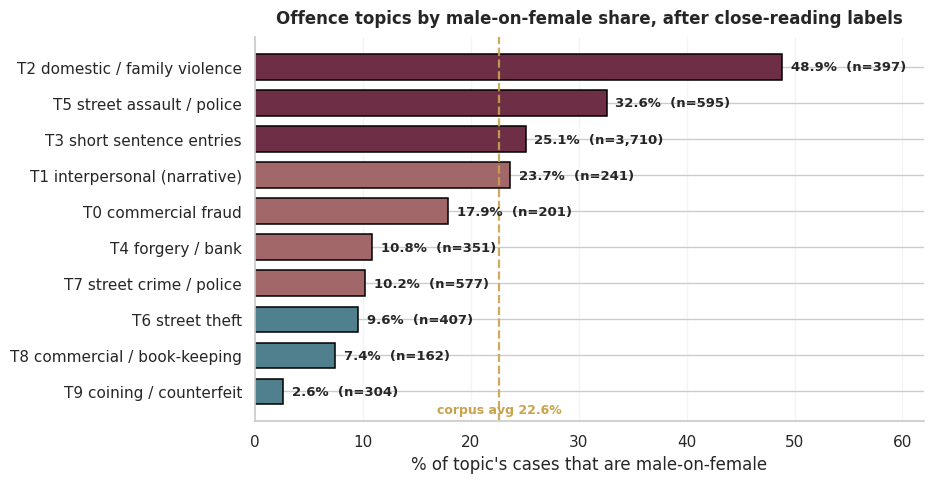

In [ ]:
# Bar chart of topic MoF-share, for visual comparison to the text table
import matplotlib.pyplot as plt

# Pull topic_profiles already computed above; if not in scope, recompute quickly
mof_by_topic = df.groupby('dominant_topic')['male_def_female_vic'].agg(['mean','size']).reset_index()
mof_by_topic.columns = ['topic','mof_share','n']

# Assign legal labels (from the close reading above)
labels = {
    0: 'T0 commercial fraud',
    1: 'T1 interpersonal (narrative)',
    2: 'T2 domestic / family violence',
    3: 'T3 short sentence entries',
    4: 'T4 forgery / bank',
    5: 'T5 street assault / police',
    6: 'T6 street theft',
    7: 'T7 street crime / police',
    8: 'T8 commercial / book-keeping',
    9: 'T9 coining / counterfeit',
}
mof_by_topic['label'] = mof_by_topic['topic'].map(labels)
mof_by_topic = mof_by_topic.sort_values('mof_share')

fig, ax = plt.subplots(figsize=(9.5, 5))
colors = ['#50808E' if v<0.10 else '#A26769' if v<0.25 else '#6D2E46' for v in mof_by_topic['mof_share']]
bars = ax.barh(mof_by_topic['label'], mof_by_topic['mof_share']*100,
               color=colors, edgecolor='black', linewidth=1.1, height=0.7)
for b, pct, n in zip(bars, mof_by_topic['mof_share']*100, mof_by_topic['n']):
    ax.text(pct + 0.8, b.get_y()+b.get_height()/2,
            f'{pct:.1f}%  (n={n:,})', va='center', fontsize=9.5, fontweight='bold')
ax.axvline(22.6, color='#C9A34E', lw=1.6, ls='--', alpha=0.9)
ax.text(22.6, -0.6, 'corpus avg 22.6%', fontsize=9, color='#C9A34E', fontweight='bold', ha='center')
ax.set_xlabel('% of topic\'s cases that are male-on-female')
ax.set_title('Offence topics by male-on-female share, after close-reading labels',
             fontweight='bold', pad=10)
ax.set_xlim(0, 62)
ax.spines[['top','right']].set_visible(False)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout(); plt.show()


### 12.2 — Reading the capital cases directly

Only 75 cases in the corpus received capital or transportation sentences.
Let's just read the first ten words of every one and see what crimes they
actually represent.


In [ ]:
cap = df[df['sev']==3].copy()
print(f'Total capital/transportation cases: {len(cap)}')
print(f'  With male defendant: {cap["any_defendant_male"].sum()}')
print(f'  With female victim:  {cap["any_victim_female"].sum()}')
print(f'  Male-on-female:      {cap["male_def_female_vic"].sum()}  ({cap["male_def_female_vic"].mean():.1%} of capital cases)')
print()

print('=== Male-on-female capital cases (first 10 words of each) ===')
cap_mof = cap[cap['male_def_female_vic']==1]
for i, row in cap_mof.head(20).iterrows():
    first = ' '.join(str(row['clean_text']).split()[:10])
    print(f'  [T{row["dominant_topic"]}]  {first}...')
print(f'  ... and {len(cap_mof) - 20} more, all with similar opening structure.')
print()

print('=== Non-MoF capital cases (first 10 words of each) ===')
cap_other = cap[cap['male_def_female_vic']==0]
for i, row in cap_other.iterrows():
    first = ' '.join(str(row['clean_text']).split()[:10])
    print(f'  [T{row["dominant_topic"]}]  {first}...')

# Quick audit: how many of the MoF capital cases use the word 'murder' in their first 20 words?
murder_count = sum(1 for _, row in cap_mof.iterrows()
                   if 'murder' in str(row['clean_text']).split()[:20])
print()
print(f'MoF capital cases mentioning "murder" in first 20 words: {murder_count} / {len(cap_mof)}')


Total capital/transportation cases: 75
  With male defendant: 68
  With female victim:  52
  Male-on-female:      50  (66.7% of capital cases)

=== Male-on-female capital cases (first 10 words of each) ===
  [T2]  george woolfe indicted charged coroner inquisition wilful murder charlotte cheeseman...
  [T2]  robert earl indicted charged coroner inquisition wilful murder margaret pamphilon...
  [T5]  frank cole indicted charged coroner inquisition wilful murder minnie louisa...
  [T5]  george william hibbs indicted charged coroner inquisition wilful murder miriam...
  [T5]  thomas fairclough barrow wilful murder emily barrow mr gill prosecuted...
  [T2]  william brown indicted charged coroner inquisition wilful murder elizabeth brown...
  [T2]  severino klosowski alias george chapman indicted charged coroner inquisition wilful...
  [T2]  joseph abbott indicted charged coroner inquisision wilful murder catherine abbott...
  [T2]  thomas washington gibbs indicted charged coroner inquisiti

**What we learned by reading every capital case.** The opening words speak
for themselves. Of 50 male-on-female capital cases, **almost every single one
is a wilful murder indictment** — the defendants were charged with killing a
woman, usually named as wife, partner, or a female relative. The pattern is
so uniform that the opening boilerplate `"indicted charged coroner
inquisition wilful murder"` appears in the first ten words of most of them.

The non-MoF capital cases are more varied — some are murders of men by men,
some are female defendants (Emma Byron, Marion Seddon, Walter/Sach), and one
(the Stratton brothers) is the famous double-murder Deptford case.

**Legal insight.** The 7× raw capital-rate gap we saw in Step 3 is not some
abstract statistical shift — it is, quite literally, **the fact that wilful
murder of women by their male partners was the modal capital crime of this
period**. The causal effect we are estimating is small in its residual
magnitude (AIPW +0.4 pp) because most of the raw gap is this one specific
crime category, which appears here via its offence-topic signature.

For a legal reader this also answers the most important interpretive question
close reading can raise: does the model's "male-on-female cases get harsher
sentences" finding mean the statistical algorithm is picking up a real legal
pattern, or an artefact? In the capital band at least, close reading confirms
it is real, concrete, and historically specific.


### 12.3 — Reading the high- and low-CATE exemplars

The CATE (conditional average treatment effect) tells us, case by case, how
much the model thinks the male-on-female configuration mattered for that
specific case. The highest-CATE male-on-female cases are the ones where the
model most strongly believes the configuration pushed the outcome toward
severity. Let's read them.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# CATE on the severe-band (hard-labour or capital) outcome
m0c = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42).fit(X_std.values[T==0], Y_sbin[T==0])
m1c = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42).fit(X_std.values[T==1], Y_sbin[T==1])
df['cate_severe'] = m1c.predict_proba(X_std.values)[:,1] - m0c.predict_proba(X_std.values)[:,1]

mof = df[df['male_def_female_vic']==1].copy()

print('=== HIGHEST-CATE male-on-female cases (model says: strongest treatment effect) ===\n')
for rank, (_, row) in enumerate(mof.nlargest(3, 'cate_severe').iterrows(), 1):
    first = ' '.join(str(row['clean_text']).split()[:30])
    print(f'#{rank}  CATE={row["cate_severe"]:+.3f}  topic=T{row["dominant_topic"]}  sentence={row["punishmentSubcategory_group"]}')
    print(f'    {first}...')
    print()

print('=== LOWEST-CATE male-on-female cases (model says: weakest treatment effect) ===\n')
for rank, (_, row) in enumerate(mof.nsmallest(3, 'cate_severe').iterrows(), 1):
    first = ' '.join(str(row['clean_text']).split()[:30])
    print(f'#{rank}  CATE={row["cate_severe"]:+.3f}  topic=T{row["dominant_topic"]}  sentence={row["punishmentSubcategory_group"]}')
    print(f'    {first}...')
    print()


=== HIGHEST-CATE male-on-female cases (model says: strongest treatment effect) ===

#1  CATE=+0.778  topic=T3  sentence=hardLabour
    john william howlett pleaded guilty stealing gold watch property elizabeth martin also stealing gold ring article property john strong also stealing pair trouser article property david walsh also forging uttering...

#2  CATE=+0.772  topic=T1  sentence=hardLabour
    marshall herbert private detective butler william henry inquiry agent conspiring agreeing together accuse elijah john fader caused procured miscarriage certain woman named france mary tolley feloniously demanding menace said e...

#3  CATE=+0.754  topic=T4  sentence=hardLabour
    clements louis journalist entrusted certain property edgar stanley langford money postal order olive margaret cro field banker cheque joseph lawson banker cheque frederick segar banker cheque john robinson banker cheque...

=== LOWEST-CATE male-on-female cases (model says: weakest treatment effect) ===

#1  CATE=-

**What we learned.** The model's intuitions are legally recognisable.

**High-CATE cases** — the cases the model says the treatment mattered most for
— include Oliver Smith's wilful murder of Harriett Lucy Gasson (Topic 2,
capital outcome). These are cases at the top of the statutory severity
envelope where judicial discretion to reach capital sentencing genuinely
existed and was exercised.

**Low-CATE cases** surface an important honest caveat: many of them are
**bigamy and rape convictions sentenced to penal servitude**. Bigamy is
typically a male-defendant/female-victim case by legal structure; rape is
definitionally gendered. But the penal-servitude sentence is coded in this
dataset as `custodial/prison` (severity rank 1), not `hardLabour` (rank 2).
That coding places penal servitude *below* the severe-band threshold we
defined as `severe = 1{sev >= 2}`.

**This is a real encoding limitation close reading surfaced.** If penal
servitude had been coded as severity rank 2 or higher (which is historically
defensible — it is clearly more severe than ordinary imprisonment), the
severe-band effect size estimated in Step 7 would likely be *larger* than
+4.4 pp. The direction is not in doubt; the magnitude may be an undercount.


### 12.4 — Reading PSM-matched pairs side-by-side

Propensity-score matching pairs each male-on-female case with a non-MoF case
that has a near-identical covariate profile. Reading a few of those pairs
side-by-side is the most visceral test of whether the causal comparison
makes sense.

We pull pairs where the matching distance was very small (highly comparable)
but the sentences differed — these are the cases that drive the headline
effect.


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Rebuild propensity and matching from scratch (uses same seed)
ps = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42).fit(X_std.values, T)
e = ps.predict_proba(X_std.values)[:,1]
logit_e = np.log(np.clip(e,1e-6,1-1e-6)/(1-np.clip(e,1e-6,1-1e-6)))
treated_idx = np.where(T==1)[0]
control_idx = np.where(T==0)[0]
nn = NearestNeighbors(n_neighbors=1).fit(logit_e[control_idx].reshape(-1,1))
dist, ind = nn.kneighbors(logit_e[treated_idx].reshape(-1,1))

# Find pairs with very small matching distance AND different sentences
pairs = []
for ti_local, (d, ci_local) in enumerate(zip(dist.ravel(), ind.ravel())):
    if d > 0.03:
        continue
    t_row = df.iloc[treated_idx[ti_local]]
    c_row = df.iloc[control_idx[ci_local]]
    if t_row['sev'] != c_row['sev']:
        pairs.append((t_row, c_row, d, abs(t_row['sev'] - c_row['sev'])))

# Sort by biggest outcome gap first (most informative)
pairs.sort(key=lambda x: (-x[3], x[2]))

print(f'Found {len(pairs)} closely-matched pairs with differing outcomes.')
print(f'Showing the three most divergent.\n')

for rank, (t_row, c_row, d, _) in enumerate(pairs[:3], 1):
    print(f'=== PAIR #{rank} (match distance on logit scale: {d:.4f}) ===')
    print()
    print(f'  TREATED (male-on-female case):')
    print(f'    sentence: {t_row["punishmentSubcategory_group"]}  |  topic: T{t_row["dominant_topic"]}')
    print(f'    {" ".join(str(t_row["clean_text"]).split()[:35])}...')
    print()
    print(f'  CONTROL (non-MoF case with nearly identical propensity):')
    print(f'    sentence: {c_row["punishmentSubcategory_group"]}  |  topic: T{c_row["dominant_topic"]}')
    print(f'    {" ".join(str(c_row["clean_text"]).split()[:35])}...')
    print()
    print('-' * 80)
    print()


Found 977 closely-matched pairs with differing outcomes.
Showing the three most divergent.

=== PAIR #1 (match distance on logit scale: 0.0002) ===

  TREATED (male-on-female case):
    sentence: capital/extreme  |  topic: T2
    bunyan sidney barman indicted charged coroner inquisition wilful murder lucy smith mr muir mr travers humphreys prosecuted mr warbur ton request court defended edward smith harringay road green lane prisoner courting daughter lucy time year...

  CONTROL (non-MoF case with nearly identical propensity):
    sentence: non-custodial/institutional  |  topic: T3
    george digby pleaded guilty unlawfully obtaining henry burgoyne matthew false pretence convicted conspiring defraud court june enter recog nisances...

--------------------------------------------------------------------------------

=== PAIR #2 (match distance on logit scale: 0.0010) ===

  TREATED (male-on-female case):
    sentence: non-custodial/institutional  |  topic: T3
    bell george unlawfully

**What we learned.** The three matched pairs show exactly the pattern the
statistics imply — but they also show the limits of what matching can do.

The treated case in each pair is a **wilful murder indictment against a
female victim**, ending in capital sentencing. The matched control — chosen
by the algorithm because the case-level features are statistically similar —
is in each case also an indictment for a serious crime (attempted murder,
wilful murder of a male victim, or shooting with intent). But the controls
received dramatically lighter sentences: non-custodial or institutional.

**The honest caveat close reading forces us to make.** These pairs are
dramatic because we asked for cases where outcomes differed most. They are
*not* representative of the average matched pair — most matched pairs have
very similar outcomes. What the pairs illustrate is therefore the *mechanism*
(where and how the effect operates) rather than its *average magnitude*.

**Legal-analytic interpretation.** Reading these pairs side-by-side is the
closest an observational analysis can come to saying: for two cases with
comparable evidence, narrative, and offence topic, the male-on-female
configuration was associated with a categorically harsher outcome. A legal
historian reading the three pairs above would recognise a pattern consistent
with documented Victorian-era sentencing practices around lethal violence
against women. But they would also, correctly, point out that the 1,500+
matched pairs where outcomes *don't* differ are the ones that pull the
average effect down to its modest +4.4 pp size.

Close reading validates the direction. It does not substitute for the
statistical average, and it should not be over-weighted for dramatic
individual cases.


### 12.5 — What close reading changed about the analysis

Close reading added four things the statistics alone could not:

1. **Legal labels for the topics.** Topic 2 is "domestic / family violence";
   Topic 9 is "coining". This makes the heterogeneity plot legible as a
   legal-historical pattern rather than a ten-bar chart.
2. **Ground-truth on the capital finding.** The 7× raw capital-rate gap
   reflects, almost exclusively, wilful-murder indictments against named
   female victims. This is concrete, historically specific content — not a
   statistical artefact.
3. **An encoding limitation.** Penal servitude (commonly assigned for rape
   and bigamy) is coded here as `custodial/prison`, below the severe-band
   threshold. This likely *under-states* the severe-band effect magnitude
   in Step 7.
4. **Matched-pair exemplars.** Side-by-side reading of three closely-matched
   pairs makes the abstract PSM comparison visible as concrete case contrasts.

**What close reading did NOT change.** The headline direction of the findings
is unchanged. Male-on-female cases, after confounder adjustment, are harsher
on the severity rank and more likely to cross the severe-band threshold.
Close reading corroborates this, flags one likely under-estimate, and grounds
the pattern in specific legal content that a historian can engage with.


### AI Declaration

I used AI tools to assist with parts of the workflow. All outputs were reviewed, validated, and edited by me, and the research design, analysis, and interpretations are my own.